In [252]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import nltk
import seaborn as sns
from nltk.corpus import stopwords
import string
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

In [253]:
df = pd.read_csv('spam.csv',encoding='latin-1')

In [254]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1162,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
324,ham,No problem. How are you doing?,NaN,NaN,NaN
4453,ham,I'm home. Ard wat time will u reach?,NaN,NaN,NaN
5509,ham,Lol they were mad at first but then they woke ...,NaN,NaN,NaN
3881,ham,Short But Cute: \Be a good person,"but dont try to prove it..\"" .Gud noon....""",NaN,NaN


In [255]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [256]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [257]:
df.sample(5)

,target,text
2735,ham,I meant middle left or right?
1602,ham,Ok pa. Nothing problem:-)
2343,ham,1) Go to write msg 2) Put on Dictionary mode 3...
3564,ham,We know TAJ MAHAL as symbol of love. But the o...
5361,ham,Yep get with the program. You're slacking.


In [258]:
encoder = LabelEncoder()

In [259]:
 df['target'] = encoder.fit_transform(df['target'])

In [260]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [261]:
df.duplicated().sum()

np.int64(403)

In [262]:
df = df.drop_duplicates(keep='first')

In [263]:
df.shape

(5169, 2)

In [264]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

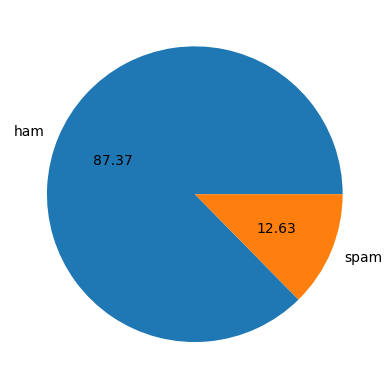

In [265]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [266]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saava\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [267]:
df['num_characters'] = df['text'].apply(len)

In [268]:
df['num_words'] =df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [269]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [270]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [271]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [272]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [273]:
  df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [274]:
  df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

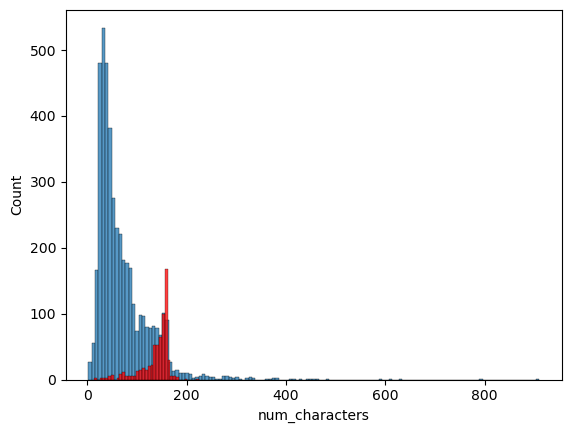

In [275]:
  sns.histplot(df[df['target']==0]['num_characters'])
  sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

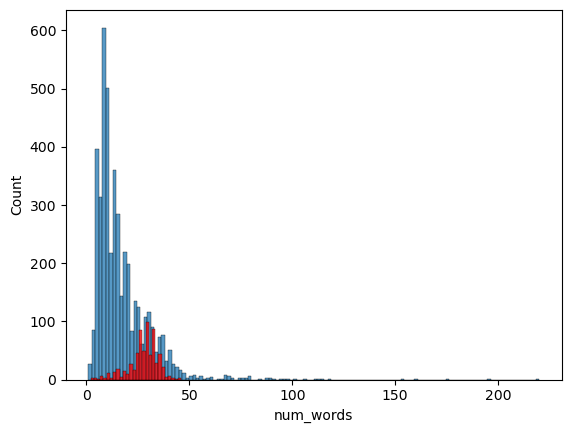

In [276]:
  sns.histplot(df[df['target']==0]['num_words'])
  sns.histplot(df[df['target']==1]['num_words'],color='red')

<Axes: xlabel='num_sentences', ylabel='Count'>

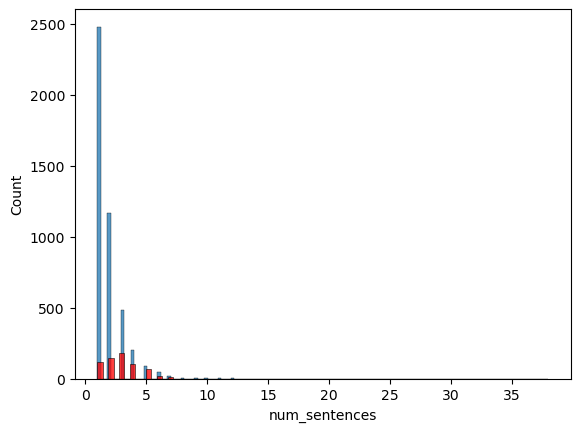

In [277]:
  sns.histplot(df[df['target']==0]['num_sentences'])
  sns.histplot(df[df['target']==1]['num_sentences'],color='red')

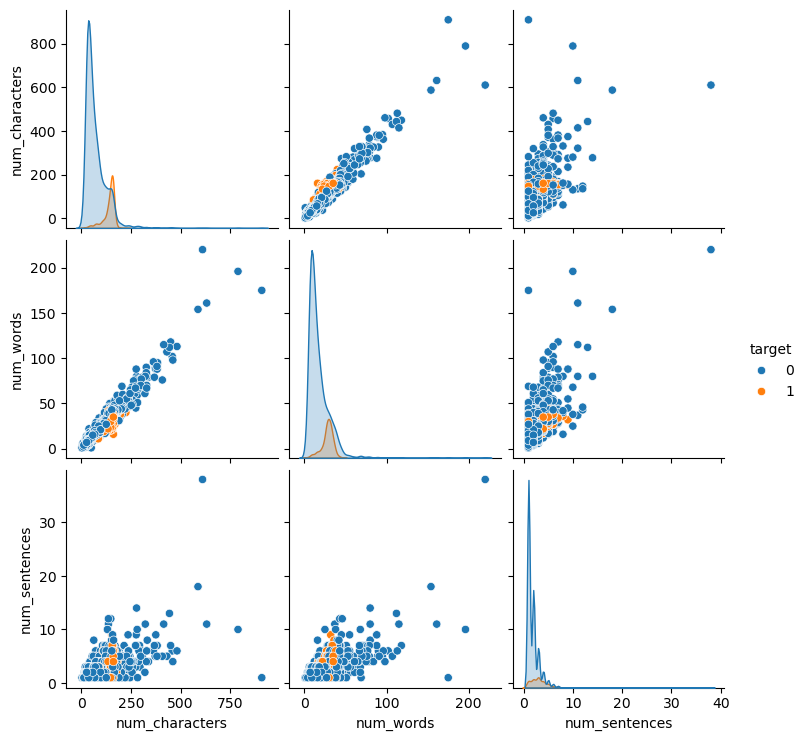

In [278]:
sns.pairplot(df,hue='target')

<Axes: >

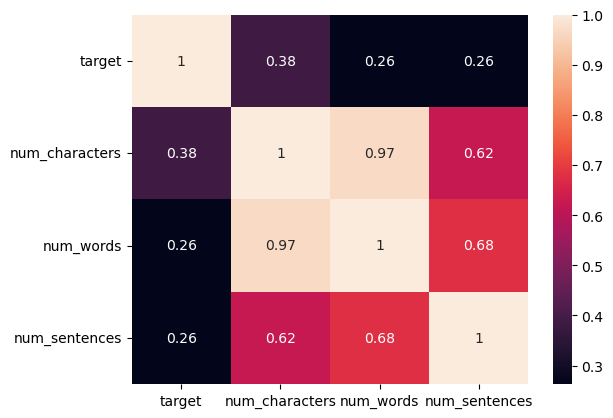

In [279]:
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(),annot=True)

In [280]:
lemma = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum() and i not in stop_words:
            y.append(lemma.lemmatize(i,pos='v'))
    return " ".join(y)

In [281]:
print(transform_text("Congratulations! You have won a free ticket. Call now!"))

congratulations free ticket call


In [282]:
df['transformed_text'] = df['text'].apply(transform_text)

In [283]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think go usf live around though


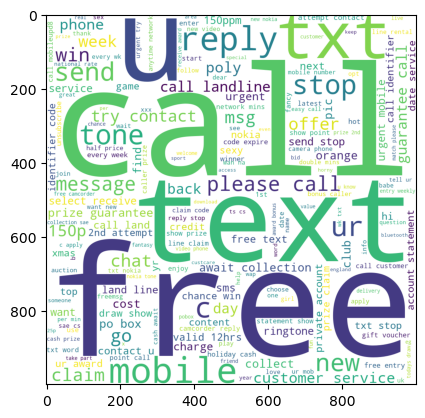

In [284]:
wc = WordCloud(width=1000,height=1000,min_font_size=10,background_color='white')
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

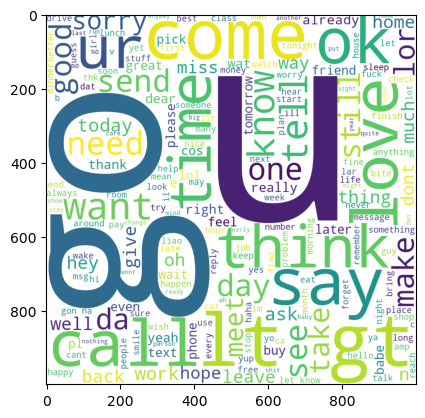

In [285]:
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

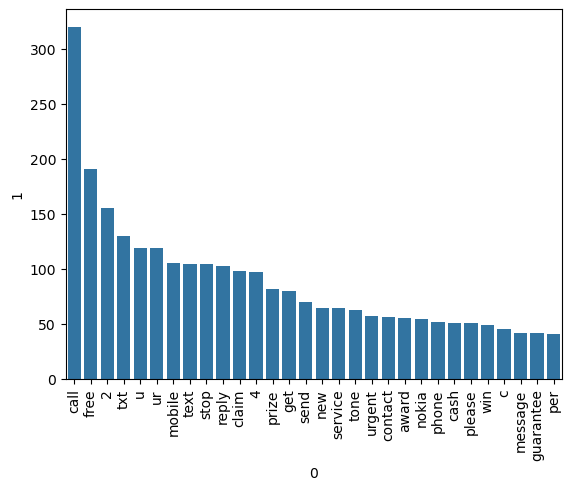

In [286]:
spam_corpus = " ".join(df[df['target']==1]['transformed_text']).split()
top_words = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=top_words[0],y=top_words[1])
plt.xticks(rotation='vertical')
plt.show()

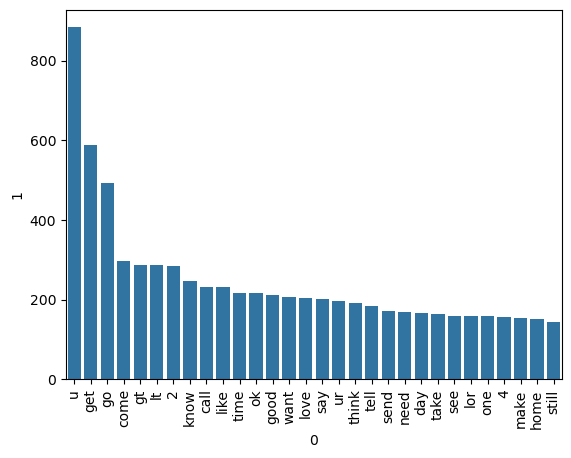

In [287]:
ham_corpus = " ".join(df[df['target']==0]['transformed_text']).split()
top_words = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x=top_words[0],y=top_words[1])
plt.xticks(rotation='vertical')
plt.show()

In [288]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf = TfidfVectorizer(max_features=3000,ngram_range=(1,2))

In [292]:
x = tf.fit_transform(df['transformed_text']) .toarray()
y = df['target'].values

In [293]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [294]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [250]:
models = {
    "MultinomialNB" : MultinomialNB(),
    "BernoulliNB" : BernoulliNB()
}
best_model = None
best_precision = 0
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    precision = precision_score(y_test,y_pred)
    print(name)
    print('Accuracy:',accuracy_score(y_test,y_pred))
    print('Confusion Matrix:\n',confusion_matrix(y_test,y_pred))
    print('Precision:',precision)
    if precision > best_precision:
        best_precision = precision
        best_model = model

MultinomialNB
Accuracy: 0.9738878143133463
Confusion Matrix:
 [[896   0]
 [ 27 111]]
Precision: 1.0
BernoulliNB
Accuracy: 0.9825918762088974
Confusion Matrix:
 [[896   0]
 [ 18 120]]
Precision: 1.0


In [251]:
import pickle
pickle.dump(tf,open('vectorizer.pkl','wb'))
pickle.dump(best_model,open('model.pkl','wb'))